# Seminar Thesis: Microeconomic Modeling on the Real Data:
## Optimizing production output with respect to budget constraint using linear regression and Newton's method

##### Subject ID: EBS15QM-EN

##### Name: Tomáš Kozák

##### Study Cycle: 2019/2021

## 1. Introduction

This seminar thesis is focused on the applied microeconomic optimization processes which include, for instance, definition of a budget constraint function, derivation of a (Cobb-Douglas) production function, framing of the computational problem with applied microeconomic optimization tools and ultimately, solving the problem using Newton’s method, as well as Langrangian with the subsequent evaluation of the results.

## 2. Computational Framework of the Problem

Dataset: used dataset consists of three variables: quantity of output produced, quantity of capital input (how much raw materials were used) and quantity of labor input (how many worker-hours were needed). Each observation in the dataset represents one week of production. One of the assumptions, according to assignment, is that the product that the company manufactures is in high demand at the moment, so the goal is to find the maximum quantity of output produced with respect to budget constraint. Apart from the output maximization, intermediary goal is to determine what quantities of labor and capital input should be used to achieve the primary goal of output maximazation. These quantities of labor and capital intputs are constrained by the company’s overall budget defined in the assignment. The nominal amount to be put into production process is 5 million, the cost of each unit of capital is 1500 and the cost of each labor input is 1920 per week. This budget can be expressed as the basic total cost function:

- C = rK + wL 

... where C is the total cost or total budget attributed to production, r is the rental rate of capital, K is the quantity of capital, w is the wage rate and L is the quantity of labor. Plugging in our values, the TC function can be looked at as:

- 5000 = 1.5K + 1.92L

Cobb-Douglas function: Paul Douglas, an economist lecturing at Amherst University in 1927, noticed an interesting relationship between three variables in some manufacturing data collected between 1899 and 1922. After performing logarithmic transformations, the index of physical production from the data could be estimated as a combination of the relative contributions of the total fixed capital and the total number of “wage earners” [1]. Subsequently, Douglas approached his colleague Charles Cobb, a mathematician, and the two discovered that the relationship could be modeled by an Euler formula of the following form:

- a) P = bL ** k C ** 1-k
- b) Q = AK ** 𝛼 L ** 𝛽

In Douglas’ own notes, he wrote the formula as it appears in equation a). For this seminar thesis, I will use the notation in equation b), where 𝛽 = (1-𝛼). With this function in place, we can calculate the relationship which capital (K) and labor (L) have with production quantity (Q). To do this, we can simply use the least squares regression. Starting by performing a logarithmic transformation on both sides of the equation:

- ln(Q) = ln(AK ** 𝛼 L ** 𝛽)
- ln(Q) = ln(A) + 𝛼ln(K) + 𝛽ln(L)

The Cobb-Douglas function in the last two equations now looks very much like a normal linear regression equation and that’s because it is. To solve for the regression coefficients, I put the variables and parameters into matrix form, solve for 𝜃 (the vector of parameters) using the closed form regression equation:

- 𝜃 = (X ** T X) ** -1 X ** T y

After solving for 𝜃, I plug the values back into the logarithmic equation and then exponentiate both sides. Performing these operations with the data gives the following Cobb-Douglas production function for this particular company:

- ln(Q) = ln(0.576) + 0.238ln(K) + 0.762ln(L)
- Q = 1.779K ** 0.238 L ** 0.762

Now, when I have the company’s budget constraint equation and the company’s production function, I can calculate what quantities of labor and capital the company should use in order to maximize its production. It is important to keep in mind that the company’s output produced is subject to the company’s total cost.

## 3. Problem solution

In [1]:
# import necessary libraries
import numpy as np
import pandas as pd
import urllib.request as url
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [45]:
# define filepath and open url
file = "https://neos-guide.org/sites/default/files/mizon_data.txt"
raw = [line.decode('utf-8').split() for line in url.urlopen(file)]

(data source [2])

In [46]:
# create pandas DataFrame, adjust it and print the shape
data = pd.DataFrame(raw[1:], columns = ['week', 'output', 'capital', 'labor'])
data.loc[71, 'labor'] = 102.240
data = data.astype(float).astype(int)
data.shape

(72, 4)

In [47]:
# regress to find Cobb-Douglas parameters
ln_y = np.log(data['output'].values)
ln_x = np.c_[np.ones((data.shape[0], 1)),
             np.log(data[['capital', 'labor']].values)]

In [5]:
betas = np.linalg.inv(ln_x.T.dot(ln_x)).dot(ln_x.T).dot(ln_y)

In [6]:
e = (1 - (betas[1] + betas[2])) / 2

beta_0 = np.exp(betas[0])
beta_1 = betas[1] + e
beta_2 = betas[2] + e

In [7]:
beta_0, beta_1, beta_2

(1.7785664111444737, 0.23837847401070866, 0.7616215259892913)

In [48]:
# formulate Cobb-Douglas function with regressed parameters
output = lambda k, l: beta_0 * k ** beta_1 * l ** beta_2

In [9]:
y_hat = np.array([output(*x) for x in data[['capital', 'labor']].values])

In [10]:
data['y_hat'] = y_hat
data.head()

,week,output,capital,labor,y_hat
0,1,378,250,270,471.483335
1,2,192,101,93,168.692644
2,3,27,63,7,21.020304
3,4,31,129,17,49.014618
4,5,417,397,201,420.464658


In order to find the optimal quantities of capital and labor, I have to find a point in the production function with the highest value. Visually, it is crucial to find the spot on the hyper-plane in the figure below at the highest point on the vertical (Output) axis.

In [49]:
# plot Cobb-Douglas function
K, L = np.meshgrid(np.arange(4000), np.arange(4000))
Q = output(K, L)

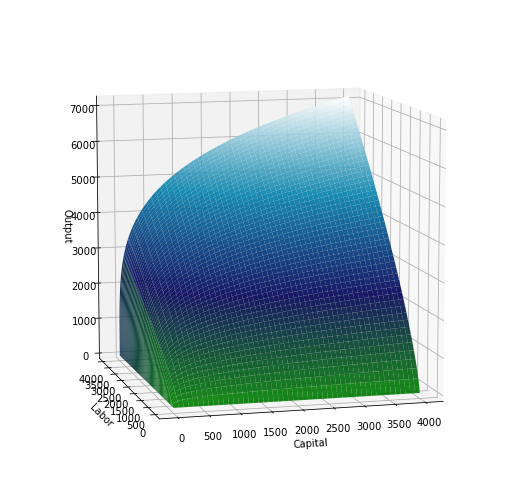

In [41]:
plt.figure(figsize = (9, 9))

ax = plt.axes(projection = '3d')
ax.plot_surface(K, L, Q, cmap = 'ocean', alpha = 0.9)

ax.view_init(10, 255)
ax.set_xlabel('Capital')
ax.set_ylabel('Labor')
ax.set_zlabel('Output')

plt.show()

It seems intuitive that in order to find the maximum y value, I simply need to go to the top corner of the hyper-plane where the color is  the lightest. However, the task becomes more difficult when I incorporate the budgetary restrictions in the next step. Isolating K and L in TC equation will define the capital and labor restraints, respectively.

In [50]:
# define budget constraint
bdgt, rent, wage = 5000, 1.5, 1.92
labor_constraint = lambda k: (bdgt - rent * k) / wage
capital_constraint = lambda l: (bdgt - wage * l) / rent

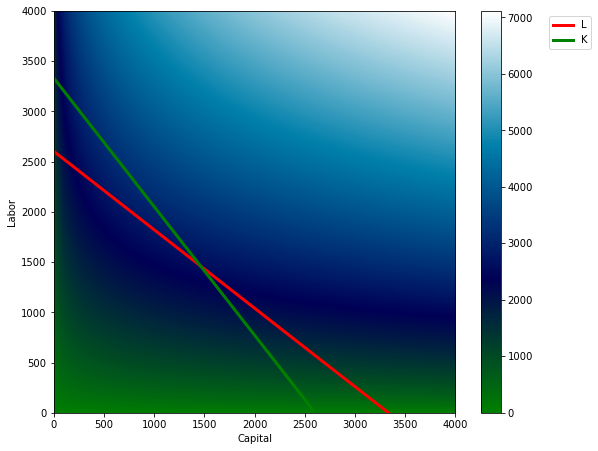

In [42]:
plt.figure(figsize = (9, 9))

plt.imshow(Q, cmap = 'ocean')
plt.plot(labor_constraint(np.linspace(0, 4000, 4000)), 'r-',
         linewidth = 3, label = 'L')
plt.plot(capital_constraint(np.linspace(0, 4000, 4000)), 'g-',
         linewidth = 3, label = 'K')

plt.xlim([0, 4000])
plt.ylim([0, 4000])
plt.xlabel('Capital')
plt.ylabel('Labor')
plt.legend(loc = 'upper right', bbox_to_anchor = (1.35, 1.0))
plt.colorbar(shrink = 0.821)
plt.show()

This figure plots the same production function as in the previous figure, but without the Output axis. The figure represents the contour of the production function against the two constraints — Capital in green and Labor in red. These constraints define the point at which the company cannot afford any additional units of either input factor. The feasible region (the region where the local optimum of this computational problem) is thus defined by the two constraints. The optimal value must lay below both lines.
To find the solution, I begin by moving the budget constraint into the objective function. This new objective function is in Lagrange form:

- a) Lg = f(x, y) + λ(c - g(x, y))
- b) Lg = AK ** 𝛼 L ** 𝛽 + λ(BC - rK -wL)
- c) Lg = 1.779K ** 0.238 L ** 0.762 + λ(5000 - 1.5K - 1.92L)

The Lagrangian equation a) shows the standard form of the single constraint Lagrange objective function. Equation b) shows the Cobb-Douglas Lagrange function. Equation c) is the equation I am attempting to solve. To do so, I will use a technique called the Newton-Raphson method (or simply Newton’s method). Chosen method is just an addition to the standard Lagrangian-based solution which will be incorporated in this seminar thesis as well.

Newton’s method is a technique for approximating the roots of a function. The goal of the technique is to converge on a point in the domain where the function’s first derivative is equal to 0. When the first derivative is 0, the function’s slope is flat and I have (hopefully) found an extremum. I can then check whether or not the extremum is a maximum, and therefore find a solution.

In the case of a single variable, Newton’s method can be very straight-forward. However, in the problem I am solving, there is more than just one variable. In order to find the maximum production quantity of equation c) with repect to budget constraint, I have to calculate the values of K, L, and λ. In order to take the first derivative of a multivariate function, I have to calculate the function’s gradient. A gradient is a vector of all the partial derivatives of the function. In order to take the second derivative, I have to calculate Hessian. Hessian is a matrix of all the second partial and cross partial derivatives of a function. Because my objective function is in Lagrange form, I have to calculate a variation of the Hessian called the Bordered Hessian.

In [51]:
# define bordered hessian
def bordered_hessian(a, k, l):
    (beta_0, beta_1, beta_2, rent, wage)
    L_kk = beta_0 * beta_1 * (beta_1 - 1) * k ** (beta_1 - 2) * l ** beta_2
    L_ll = beta_0 * beta_2 * (beta_2 - 1) * k ** beta_1 * l ** (beta_2 - 2)
    L_kl = L_lk = beta_0 * beta_1 * beta_2 * k ** (beta_1-1) * l ** (beta_2-1)
    return np.array([
                    [0, - rent, - wage],
                    [- rent, L_kk, L_kl],
                    [- wage, L_lk, L_ll]
                    ])

In [1]:
# define gradient function
def gradient(a, k, l):
    (beta_0, beta_1, beta_2, rent, wage, bdgt)
    L_a = bdgt - rent * k - wage * l
    L_k = beta_0 * beta_1 * k ** (beta_1 - 1) * l ** beta_2 - a * rent
    L_l = beta_0 * beta_2 * k ** beta_1 * l ** (beta_2 - 1) - a * wage
    return np.array([
        [L_a], [L_k], [L_l]
        ])

In [53]:
# solve the problem using Newton's method 
targets = np.array([[1], [data['capital'].mean()], [data['labor'].mean()]])

for i in np.arange(30):
    previous = targets
    h = bordered_hessian(*targets.flatten())
    g = gradient(*targets.flatten())
    step = np.linalg.inv(h).dot(g)
    targets = targets - step
    if round(np.sum(targets - previous), 10) == 0:
        break
    else:
        print(i + 1, [round(1, 10) for i in targets.flatten()])

1 [1, 1, 1]
2 [1, 1, 1]
3 [1, 1, 1]
4 [1, 1, 1]
5 [1, 1, 1]
6 [1, 1, 1]
7 [1, 1, 1]


In [55]:
# print the solution
print('Optimal quantity of capital input: {:.2f}'.format(targets[1][0]))
print('Optimal quantity of labor input: {:.2f}'.format(targets[2][0]))
print('Optimal level of Production: {:.2f}'.format(output(*targets.flatten()[1:])))

Optimal quantity of capital input: 794.59
Optimal quantity of labor input: 1983.39
Optimal level of Production: 2836.48


In [56]:
# print the first 3 principal minors
B = bordered_hessian(*targets.flatten())
print('',
      np.linalg.det(B[:1, :1]),
      np.linalg.det(B[:2, :2]),
      np.linalg.det(B[:3, :3]),
      sep = '   |H|:  ')

   |H|:  0.0   |H|:  -2.25   |H|:  0.0051834395150712545


In [57]:
# print the gradient
print(gradient(*targets.flatten()).flatten())

[-4.54747351e-13 -3.33066907e-16  0.00000000e+00]


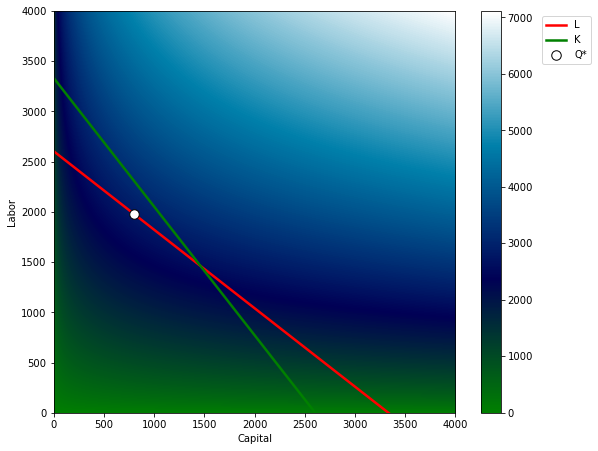

In [58]:
# plot the solution
plt.figure(figsize = (9, 9))

plt.imshow(Q, cmap = 'ocean')
plt.plot(labor_constraint(np.linspace(0, 4000, 4000)), 'r-',
         linewidth = 2.5, label = 'L')
plt.plot(capital_constraint(np.linspace(0, 4000, 4000)), 'g-',
         linewidth = 2.5, label = 'K')

plt.plot(*targets[1:], 'w.', label = 'Q*', mec = 'k', ms = 19)

plt.xlim([0, 4000])
plt.ylim([0, 4000])
plt.xlabel('Capital')
plt.ylabel('Labor')
plt.legend(loc = 'upper right', bbox_to_anchor = (1.35, 1.0))
plt.colorbar(shrink = 0.821)

plt.show()

In the last section, for the sake of the complexity of this seminar thesis, I also solve this computational problem using the Lagrangian:

In [61]:
# solve for variables using Lagrangian
lg_maximum = ((beta_1 * bdgt) / rent, (beta_2 * bdgt) / wage)
lg_lambda = rent / (bdgt / (rent + rent * beta_2 / beta_1))
print('Capital: {:.2f}'.format(lg_maximum[0]))
print('Labor: {:.2f}'.format(lg_maximum[1]))
print('Lambda: {:.4f}'.format(lg_lambda))

Capital: 794.59
Labor: 1983.39
Lambda: 0.0019


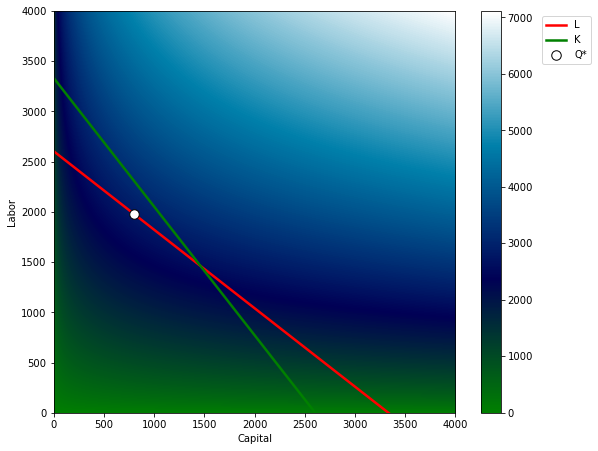

In [60]:
# plot the solution
plt.figure(figsize = (9, 9))

plt.imshow(Q, cmap = 'ocean')
plt.plot(labor_constraint(np.linspace(0, 4000, 4000)), 'r-',
         linewidth = 2.5, label = 'L')
plt.plot(capital_constraint(np.linspace(0, 4000, 4000)), 'g-',
         linewidth = 2.5, label = 'K')

plt.plot(*true_maximum, 'w.', label = 'Q*', mec = 'k', ms = 19)

plt.xlim([0, 4000])
plt.ylim([0, 4000])
plt.xlabel('Capital')
plt.ylabel('Labor')
plt.legend(loc = 'upper right', bbox_to_anchor = (1.35, 1.0))
plt.colorbar(shrink = 0.821)

plt.show()

In [62]:
# print the solution
print('Optimal quantity of capital: {:.2f}'.format(lg_maximum[0]))
print('Optimal quantity of Labor: {:.2f}'.format(lg_maximum[1]))
print('Optimal level of production: {:.2f}'.format(output(lg_maximum[0], lg_maximum[1])))

Optimal quantity of capital: 794.59
Optimal quantity of Labor: 1983.39
Optimal level of production: 2836.48


In [63]:
# print the first 3 principal minors
B = bordered_hessian(lg_lambda, lg_maximum[0], lg_maximum[1])
print('',
      np.linalg.det(B[:1, :1]),
      np.linalg.det(B[:2, :2]),
      np.linalg.det(B[:3, :3]),
      sep = '   |H|: ')

   |H|: 0.0   |H|: -2.25   |H|: 0.0051834395150712545


In [64]:
# print the gradient
print(gradient(lg_lambda, lg_maximum[0], lg_maximum[1]).flatten())

[0.         0.84811156 1.0855828 ]


## 4. Conclusion

In this seminar thesis, I was given several pieces of information: a dataset of capital inputs, labor inputs, production output and company’s budget constraint. From the dataset, I regressed coefficients relating the inputs to the output and then derived a production function. From the budget constraint information, I defined a budget (TC) function. In order to find the quantities of inputs that maximized output, I defined an objective function and then calculated an extremum. I confirmed that this extremum was a maximum by analyzing the differentials of the objective function.

In simplicity, I turned raw real-world data into a cogent solution to the company’s production problem. As mentioned in the introduction, using Newton’s method to optimize a Cobb-Douglas function was not necessary. A little bit of calculus and some linear algebra would have brought me to the same solution in a much more straight-forward way. However, I wanted to demonstrate the technique so that it can be used for more complicated problems in the future (such as optimization of loss functions in ML problems).

## 5. References

[1] Biddle, J. (2012). Retrospectives - The Introduction of the Cobb–Douglas Regression. Journal of Economic Perspectives.

[2] Mizon, G. (1977). Inferential Procedures in Nonlinear Models: An Application in a UK Industrial Cross Section Study of Factor Substitution and Returns to Scale. The Econometric Society. [Data].